In [69]:
# 📌 1. Project Overview

In [70]:
# 📂 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup completed successfully!")


Setup completed successfully!


In [71]:
# 📁 3. Load Datasets

In [72]:
import pandas as pd

trades = pd.read_csv(r'C:\Users\abhay\Downloads\historical_data.csv')
sentiment = pd.read_csv(r'C:\Users\abhay\Downloads\fear_greed_index.csv')

trades.columns = trades.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

print("Trades columns:")
print(trades.columns.tolist())

print("\nSentiment columns:")
print(sentiment.columns.tolist())

Trades columns:
['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp']

Sentiment columns:
['timestamp', 'value', 'classification', 'date']


In [16]:
trades.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [17]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [18]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

print(trades.columns)
print(sentiment.columns)


Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='str')
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [19]:
print(trades.columns.tolist())

['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp']


In [21]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  str    
 1   coin              211224 non-null  str    
 2   execution price   211224 non-null  float64
 3   size tokens       211224 non-null  float64
 4   size usd          211224 non-null  float64
 5   side              211224 non-null  str    
 6   timestamp ist     211224 non-null  str    
 7   start position    211224 non-null  float64
 8   direction         211224 non-null  str    
 9   closed pnl        211224 non-null  float64
 10  transaction hash  211224 non-null  str    
 11  order id          211224 non-null  int64  
 12  crossed           211224 non-null  bool   
 13  fee               211224 non-null  float64
 14  trade id          211224 non-null  float64
 15  timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [22]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [23]:
trades.describe()

,execution price,size tokens,size usd,start position,closed pnl,order id,fee,trade id,timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [24]:
trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    errors='coerce'
)

trades['date'] = trades['timestamp ist'].dt.date

trades[['timestamp ist','date']].head()

,timestamp ist,date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


In [26]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
)

sentiment['date'] = sentiment['date'].dt.date

In [27]:
merged = pd.merge(
    trades,
    sentiment[['date','classification','value']],
    on='date',
    how='left'
)

print(merged.shape)
merged.head()

(211224, 19)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,70.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,70.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,70.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,70.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,70.0


In [28]:
merged['classification'].isnull().sum()

175360

In [29]:
merged[['date','classification']].head()

,date,classification
0,2024-02-12,Greed
1,2024-02-12,Greed
2,2024-02-12,Greed
3,2024-02-12,Greed
4,2024-02-12,Greed


In [31]:
merged = merged.dropna(
    subset=['classification']
)

print(merged.shape)

(35864, 19)


In [32]:
merged = merged.dropna(subset=['classification'])

print("New Shape:", merged.shape)

New Shape: (35864, 19)


In [33]:
merged.isnull().sum()

account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
classification      0
value               0
dtype: int64

In [34]:
numeric_cols = [
    'execution price',
    'size tokens',
    'size usd',
    'start position',
    'closed pnl'
]

for col in numeric_cols:
    merged[col] = pd.to_numeric(
        merged[col],
        errors='coerce'
    )

In [35]:
merged.dtypes

account                        str
coin                           str
execution price            float64
size tokens                float64
size usd                   float64
side                           str
timestamp ist       datetime64[us]
start position             float64
direction                      str
closed pnl                 float64
transaction hash               str
order id                     int64
crossed                       bool
fee                        float64
trade id                   float64
timestamp                  float64
date                        object
classification                 str
value                      float64
dtype: object

In [36]:
merged.describe()

,execution price,size tokens,size usd,timestamp ist,start position,closed pnl,order id,fee,trade id,timestamp,value
count,35864.000000,3.586400e+04,3.586400e+04,35864,3.586400e+04,35864.000000,3.586400e+04,35864.000000,3.586400e+04,3.586400e+04,35864.00000
mean,7596.431745,1.004709e+04,4.920359e+03,2024-11-29 15:03:36.594914,2.701678e+04,101.070948,5.844251e+10,1.028091,5.619946e+14,1.732824e+12,51.33496
min,0.000005,5.630000e-06,0.000000e+00,2023-01-05 01:06:00,-1.050000e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,15.00000
25%,3.245975,2.588700e+00,1.665300e+02,2024-09-12 12:47:00,-2.638983e+02,0.000000,5.240387e+10,0.012518,2.780000e+14,1.730000e+12,28.00000
50%,16.390000,2.820000e+01,5.979050e+02,2025-01-05 07:06:00,7.010137e+01,0.000000,6.815193e+10,0.084384,5.620000e+14,1.740000e+12,49.00000
75%,172.590000,1.990000e+02,2.220243e+03,2025-03-04 13:18:00,1.090053e+04,10.735428,7.641909e+10,0.398132,8.460000e+14,1.740000e+12,72.00000
max,103265.000000,1.582244e+07,1.190250e+06,2025-05-02 23:59:00,3.050948e+07,71535.716740,9.014923e+10,212.298921,1.130000e+15,1.750000e+12,90.00000
std,23547.203213,2.060973e+05,2.203314e+04,NaN,4.308246e+05,1364.610762,2.240666e+10,4.937482,3.262737e+14,1.082266e+10,22.06305


In [37]:
merged['classification'].value_counts()

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

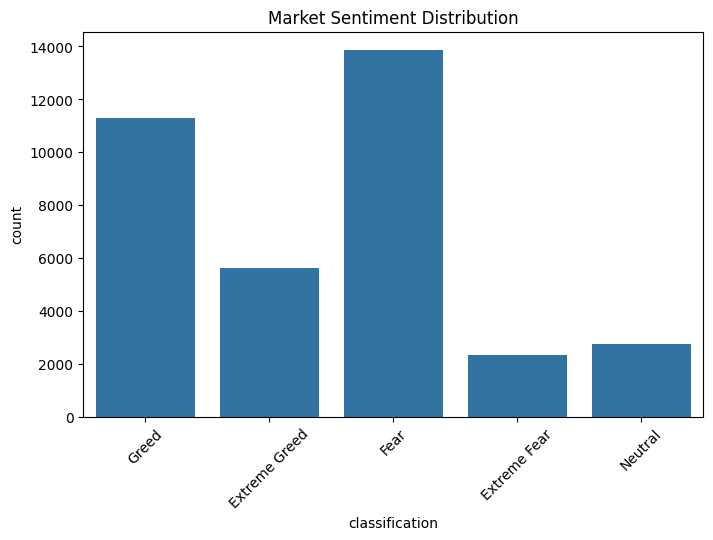

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title("Market Sentiment Distribution")

plt.xticks(rotation=45)

plt.show()

In [39]:
avg_pnl = merged.groupby(
    'classification'
)['closed pnl'].mean()

print(avg_pnl)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closed pnl, dtype: float64


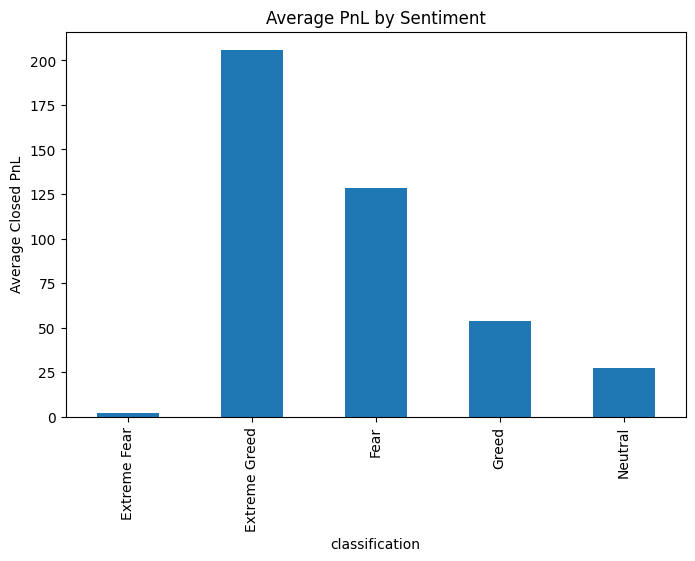

In [40]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind='bar')

plt.title(
    "Average PnL by Sentiment"
)

plt.ylabel("Average Closed PnL")

plt.show()

In [41]:
total_pnl = merged.groupby(
    'classification'
)['closed pnl'].sum()

print(total_pnl)

classification
Extreme Fear     4.399937e+03
Extreme Greed    1.156894e+06
Fear             1.779226e+06
Greed            6.096325e+05
Neutral          7.465674e+04
Name: closed pnl, dtype: float64


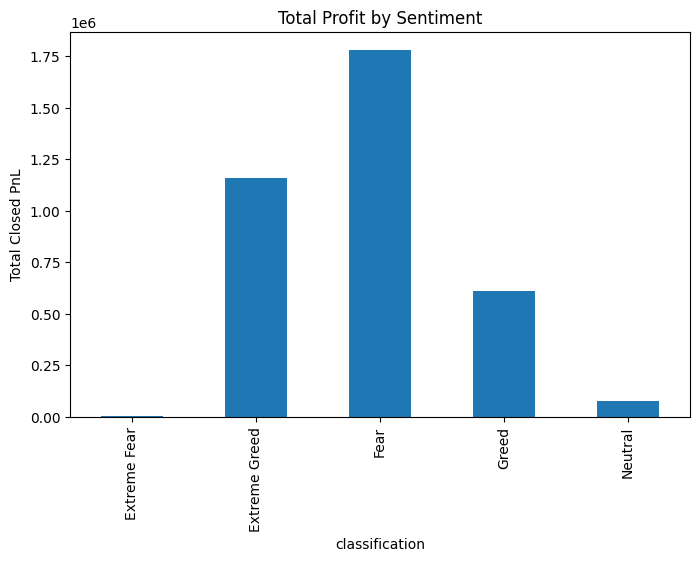

In [42]:
plt.figure(figsize=(8,5))

total_pnl.plot(kind='bar')

plt.title(
    "Total Profit by Sentiment"
)

plt.ylabel("Total Closed PnL")

plt.show()

In [43]:
merged['win'] = merged['closed pnl'] > 0

In [44]:
win_rate = (
    merged.groupby(
        'classification'
    )['win']
    .mean()*100
)

print(win_rate)

classification
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: win, dtype: float64


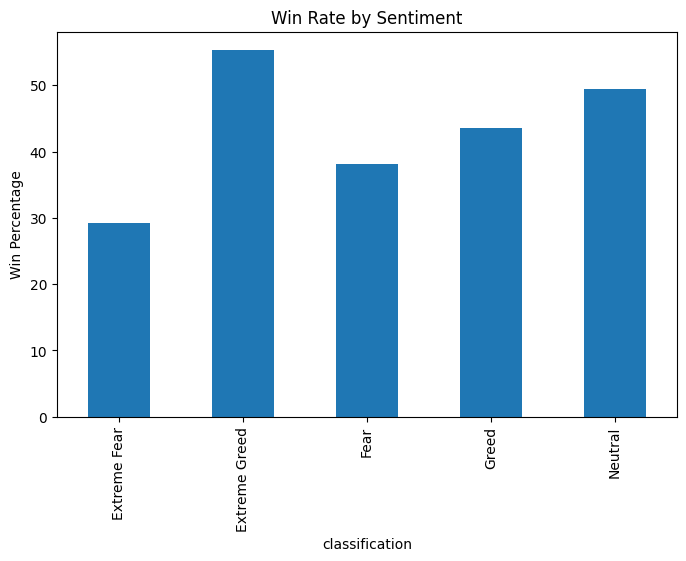

In [45]:
plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title(
    "Win Rate by Sentiment"
)

plt.ylabel("Win Percentage")

plt.show()

In [46]:
pd.crosstab(
    merged['classification'],
    merged['side']
)

side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736


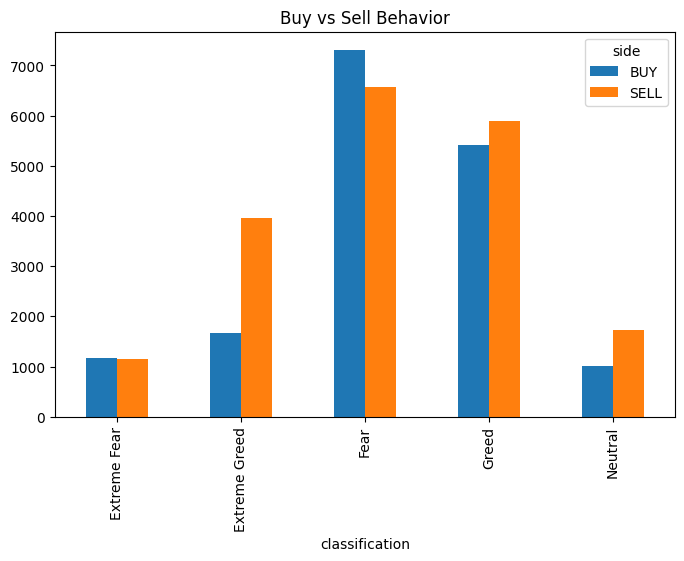

In [47]:
pd.crosstab(
    merged['classification'],
    merged['side']
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Buy vs Sell Behavior"
)

plt.show()

In [48]:
volume = merged.groupby(
    'classification'
)['size usd'].sum()

print(volume)

classification
Extreme Fear      9580240.04
Extreme Greed    18223760.27
Fear             79674391.06
Greed            57045815.74
Neutral          11939551.21
Name: size usd, dtype: float64


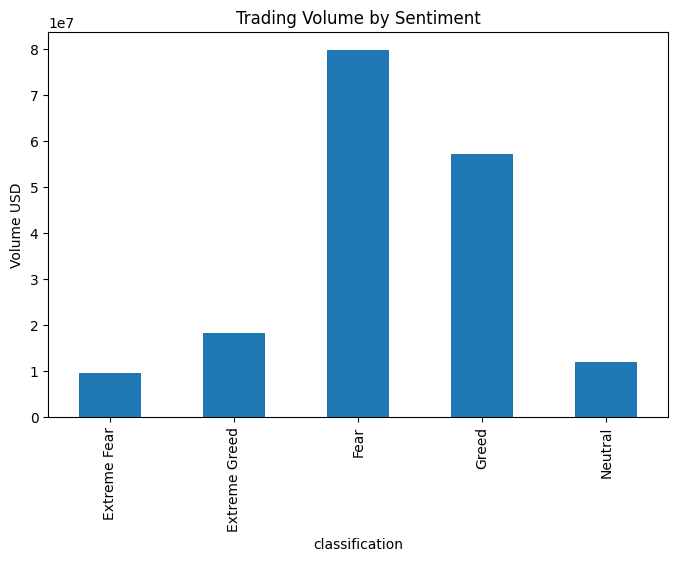

In [49]:
plt.figure(figsize=(8,5))

volume.plot(kind='bar')

plt.title(
    "Trading Volume by Sentiment"
)

plt.ylabel("Volume USD")

plt.show()

In [50]:
top_traders = (
    merged.groupby(
        'account'
    )['closed pnl']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_traders

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.478495e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    9.655887e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    2.056523e+05
0xbaaaf6571ab7d571043ff1e313a9609a10637864    2.013539e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1.972949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    1.425837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.054430e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5.853488e+04
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    4.509997e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd    4.304078e+04
Name: closed pnl, dtype: float64

In [51]:
worst_traders = (
    merged.groupby(
        'account'
    )['closed pnl']
    .sum()
    .sort_values()
    .head(10)
)

worst_traders

account
0x39cef799f8b69da1995852eea189df24eb5cae3c   -4320.315052
0x8477e447846c758f5a675856001ea72298fd9cb5   -2648.424758
0x72743ae2822edd658c0c50608fd7c5c501b2afbd       0.000000
0x430f09841d65beb3f27765503d0f850b8bce7713       0.000000
0x271b280974205ca63b716753467d5a371de622ab     208.817460
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     229.321727
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     444.205198
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    1536.976938
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1762.460000
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb    2075.015240
Name: closed pnl, dtype: float64

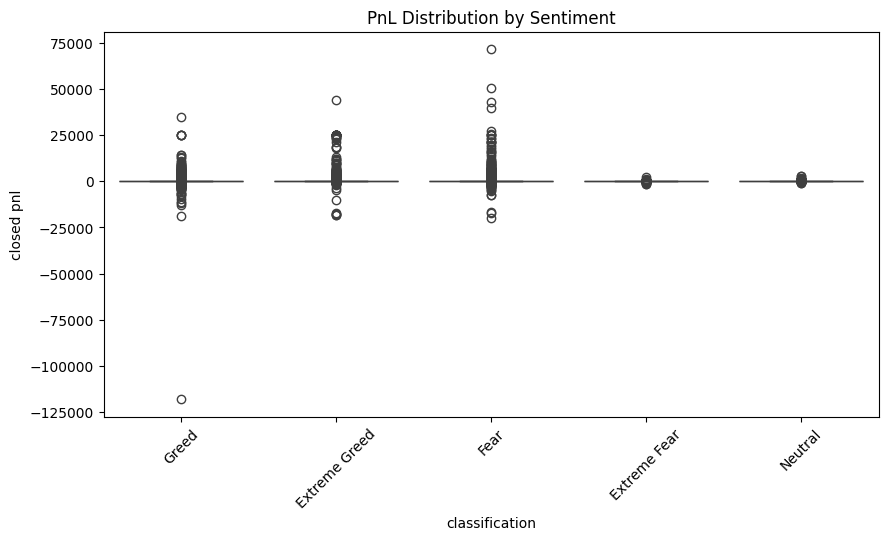

In [52]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='closed pnl'
)

plt.xticks(rotation=45)

plt.title(
    "PnL Distribution by Sentiment"
)

plt.show()

In [53]:
summary = merged.groupby(
    'classification'
).agg({
    'closed pnl':['mean','sum'],
    'size usd':['mean','sum']
})

summary

closed pnl                   size usd             
                      mean           sum         mean          sum
classification                                                    
Extreme Fear      1.891632  4.399937e+03  4118.761840   9580240.04
Extreme Greed   205.816345  1.156894e+06  3242.085086  18223760.27
Fear            128.287950  1.779226e+06  5744.782685  79674391.06
Greed            53.988003  6.096325e+05  5051.878829  57045815.74
Neutral          27.088803  7.465674e+04  4332.202906  11939551.21

In [54]:
pd.crosstab(
    merged['classification'],
    merged['side']
)

side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736


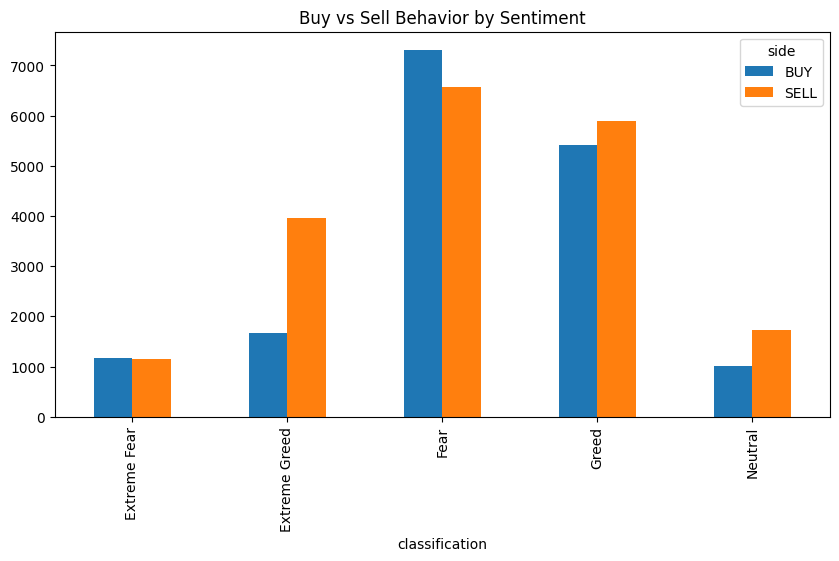

In [55]:
pd.crosstab(
    merged['classification'],
    merged['side']
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Buy vs Sell Behavior by Sentiment")

plt.show()

In [56]:
volume = merged.groupby(
    'classification'
)['size usd'].sum()

print(volume)

classification
Extreme Fear      9580240.04
Extreme Greed    18223760.27
Fear             79674391.06
Greed            57045815.74
Neutral          11939551.21
Name: size usd, dtype: float64


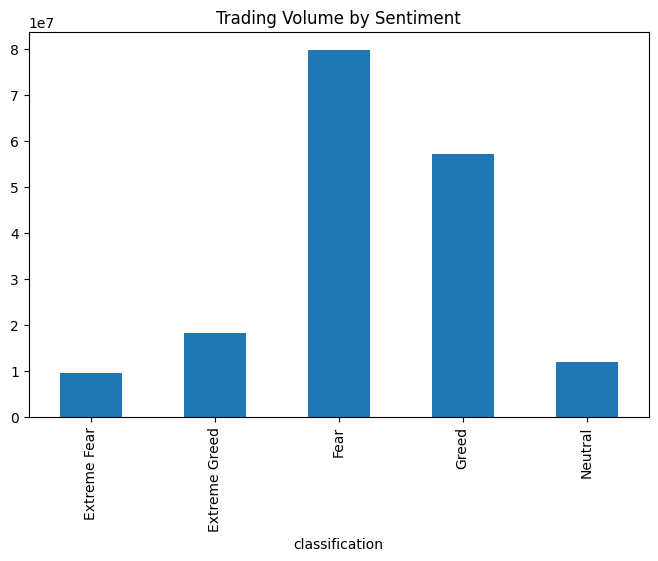

In [57]:
volume.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Trading Volume by Sentiment'
)

plt.show()

In [58]:
top_traders = (
    merged.groupby(
        'account'
    )['closed pnl']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_traders

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.478495e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    9.655887e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    2.056523e+05
0xbaaaf6571ab7d571043ff1e313a9609a10637864    2.013539e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1.972949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    1.425837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.054430e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5.853488e+04
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    4.509997e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd    4.304078e+04
Name: closed pnl, dtype: float64

In [59]:
worst_traders = (
    merged.groupby(
        'account'
    )['closed pnl']
    .sum()
    .sort_values()
    .head(10)
)

worst_traders

account
0x39cef799f8b69da1995852eea189df24eb5cae3c   -4320.315052
0x8477e447846c758f5a675856001ea72298fd9cb5   -2648.424758
0x72743ae2822edd658c0c50608fd7c5c501b2afbd       0.000000
0x430f09841d65beb3f27765503d0f850b8bce7713       0.000000
0x271b280974205ca63b716753467d5a371de622ab     208.817460
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     229.321727
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     444.205198
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    1536.976938
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1762.460000
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb    2075.015240
Name: closed pnl, dtype: float64

In [60]:
merged.groupby(
    'classification'
)['closed pnl'].std()

classification
Extreme Fear       76.727713
Extreme Greed    1861.557119
Fear             1342.348497
Greed            1399.468182
Neutral           142.945889
Name: closed pnl, dtype: float64

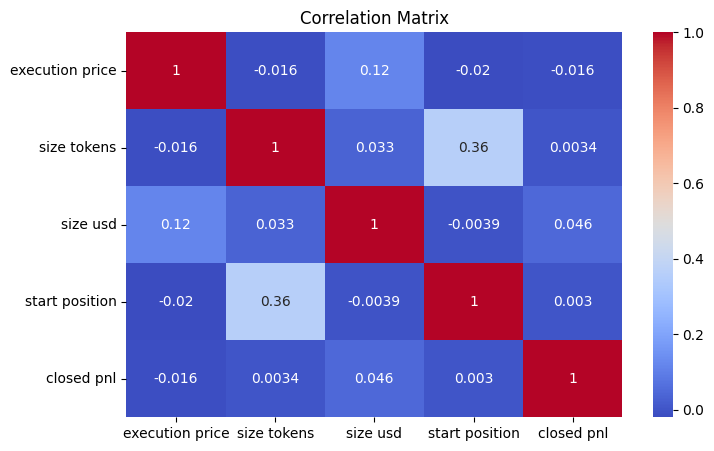

In [61]:
plt.figure(figsize=(8,5))

sns.heatmap(
    merged[
        [
            'execution price',
            'size tokens',
            'size usd',
            'start position',
            'closed pnl'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

In [62]:
plt.savefig(
    'chart_name.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

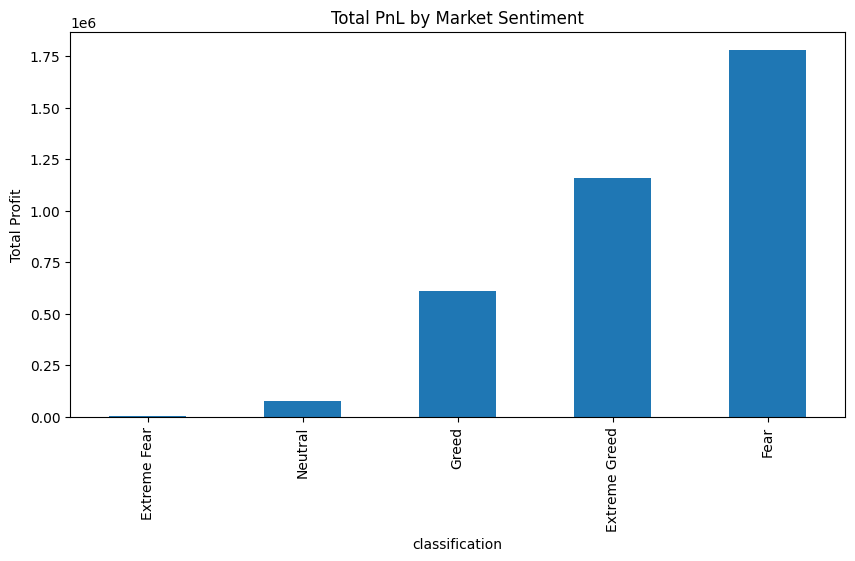

In [63]:
plt.figure(figsize=(10,5))

merged.groupby('classification')['closed pnl']\
.sum()\
.sort_values()\
.plot(kind='bar')

plt.title('Total PnL by Market Sentiment')
plt.ylabel('Total Profit')
plt.show()

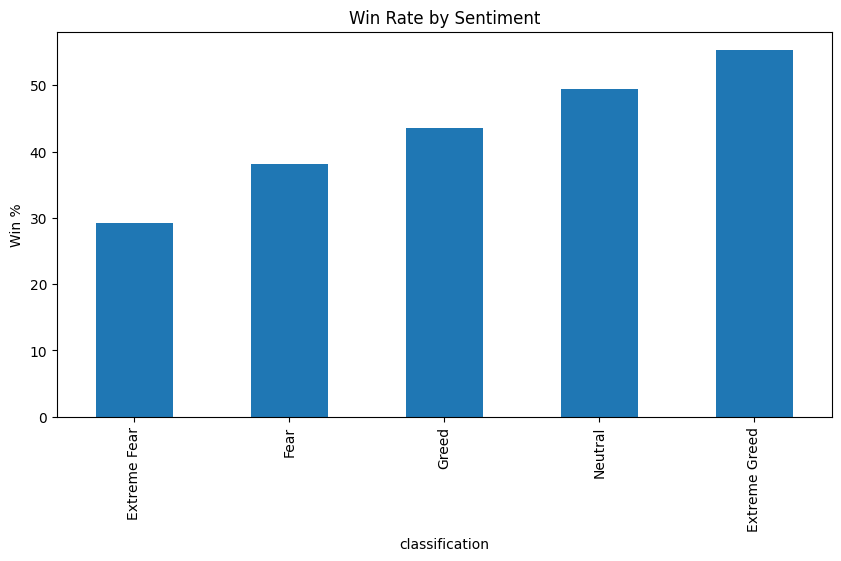

In [64]:
plt.figure(figsize=(10,5))

win_rate.sort_values().plot(kind='bar')

plt.title('Win Rate by Sentiment')
plt.ylabel('Win %')
plt.show()

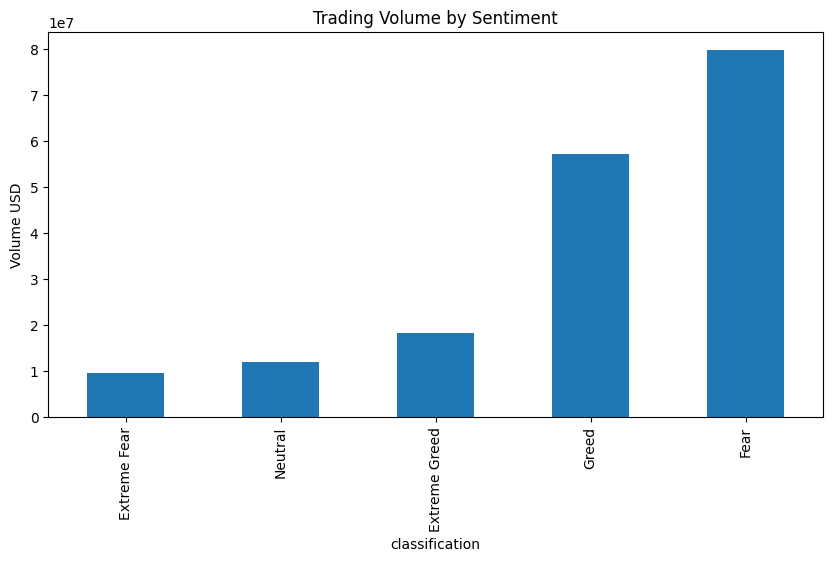

In [65]:
plt.figure(figsize=(10,5))

volume.sort_values().plot(kind='bar')

plt.title('Trading Volume by Sentiment')
plt.ylabel('Volume USD')
plt.show()

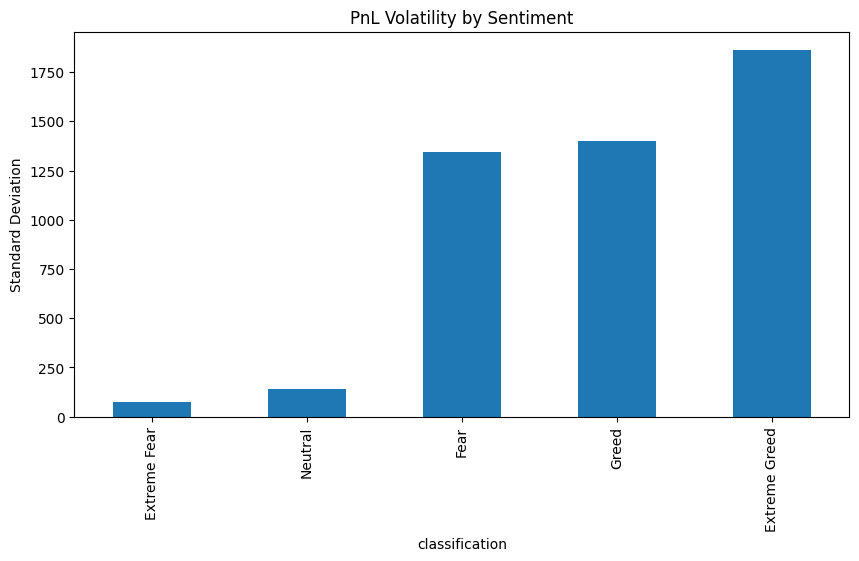

In [66]:
volatility = merged.groupby(
    'classification'
)['closed pnl'].std()

plt.figure(figsize=(10,5))

volatility.sort_values().plot(
    kind='bar'
)

plt.title(
    'PnL Volatility by Sentiment'
)

plt.ylabel(
    'Standard Deviation'
)

plt.show()

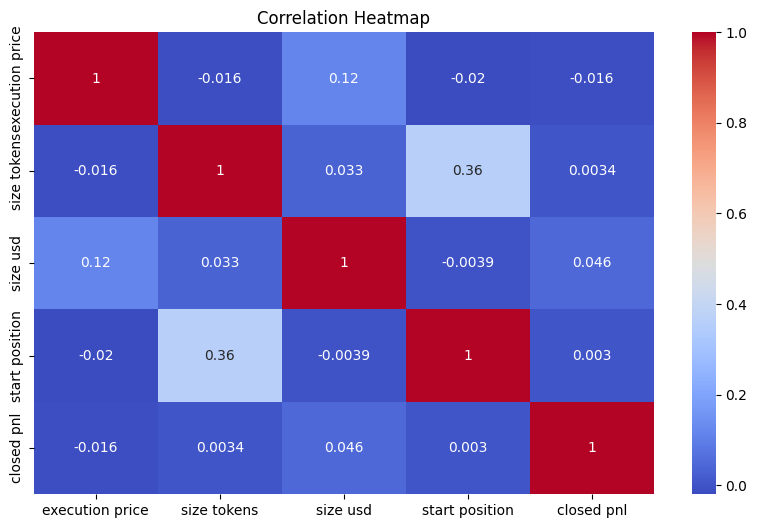

In [67]:
plt.figure(figsize=(10,6))

sns.heatmap(
    merged[
        [
            'execution price',
            'size tokens',
            'size usd',
            'start position',
            'closed pnl'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

In [1]:
import os

print(os.getcwd())

C:\Users\abhay\Crypto_Sentiment_Assignment\notebooks
